# **TỔNG QUAN DEEP LEARNING — TỪ CƠ BẢN ĐẾN KIẾN TRÚC HIỆN ĐẠI**  
---

## 0) Thiết lập chung
- Dùng Python, PyTorch, scikit-learn, torchvision, matplotlib.
- Xác định `device` (GPU nếu có) và đặt `seed` để tái lặp.

In [1]:
import os, sys, time, math, random, numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(123)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 1) Giới thiệu — Demo: đường biên tuyến tính vs. phi tuyến (Iris, 2 lớp)
**Mục tiêu:** Thấy khác biệt giữa mô hình tuyến tính và MLP phi tuyến trên dữ liệu thật (Iris).  
**Dữ liệu:** `sklearn.datasets.load_iris()` (chọn 2 lớp để minh hoạ).

Accuracy Logistic: 1.0
Accuracy MLP: 1.0


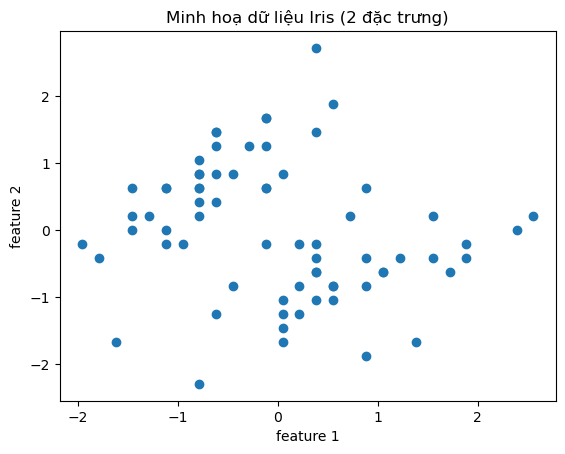

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X = data['data'][:, :2].astype(np.float32)  # dùng 2 đặc trưng để minh hoạ nhanh
y = data['target']
mask = y != 2  # chỉ lấy hai lớp (0 và 1)
X, y = X[mask], y[mask]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=123)
sc = StandardScaler()
Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

logreg = LogisticRegression().fit(Xtr, ytr)
mlp = MLPClassifier(hidden_layer_sizes=(16,16), max_iter=500, random_state=123).fit(Xtr, ytr)

print("Accuracy Logistic:", round(accuracy_score(yte, logreg.predict(Xte)), 3))
print("Accuracy MLP:", round(accuracy_score(yte, mlp.predict(Xte)), 3))

plt.figure()
plt.scatter(Xtr[:,0], Xtr[:,1])
plt.title("Minh hoạ dữ liệu Iris (2 đặc trưng)")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

## 2) Mạng nơ-ron — Demo neuron & hàm kích hoạt
**Mục tiêu:** Tính toán đầu ra neuron: \( z = w\cdot x + b \), \( y = \phi(z) \).  
Thử các activation phổ biến (sigmoid, tanh, ReLU).

In [3]:
import numpy as np

x = np.array([0.6, -1.2, 0.3], dtype=np.float32)
w = np.array([0.8, 0.5, -0.4], dtype=np.float32)
b = 0.1

def sigmoid(z): return 1/(1+np.exp(-z))
def tanh(z): return np.tanh(z)
def relu(z): return np.maximum(0,z)

z = (w*x).sum() + b
print("z =", float(z))
print("sigmoid(z) =", float(sigmoid(z)))
print("tanh(z) =", float(tanh(z)))
print("ReLU(z) =", float(relu(z)))

z = -0.14000001549720764
sigmoid(z) = 0.46505704522132874
tanh(z) = -0.13909246027469635
ReLU(z) = 0.0


## 3) Perceptron đơn lớp (SLP) — Demo phân loại nhị phân (Iris, 2 lớp)
**Mục tiêu:** Áp dụng Perceptron (ranh giới tuyến tính) trên dữ liệu thật.  
**Dữ liệu:** `Iris` (2 lớp).

In [4]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, confusion_matrix

perc = Perceptron(max_iter=1000, random_state=123).fit(Xtr, ytr)
y_pred = perc.predict(Xte)
print("Accuracy (Perceptron):", round(accuracy_score(yte, y_pred), 3))
print("\nClassification report:\n", classification_report(yte, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(yte, y_pred))

Accuracy (Perceptron): 1.0

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      1.000     1.000     1.000        15

    accuracy                          1.000        30
   macro avg      1.000     1.000     1.000        30
weighted avg      1.000     1.000     1.000        30

Confusion Matrix:
 [[15  0]
 [ 0 15]]


## 4) MLP (Multilayer Perceptron) — Demo phân loại **Wine** (tabular, thật)
**Mục tiêu:** Huấn luyện MLP nhỏ trên dữ liệu Wine (3 lớp).  
**Dữ liệu:** `sklearn.datasets.load_wine()`.

Epoch 01: train_loss=1.0776 acc=0.395 | val_loss=1.0494 acc=0.630
Epoch 02: train_loss=1.0233 acc=0.589 | val_loss=0.9870 acc=0.778
Epoch 03: train_loss=0.9450 acc=0.815 | val_loss=0.9224 acc=0.852
Epoch 04: train_loss=0.8823 acc=0.855 | val_loss=0.8537 acc=0.889
Epoch 05: train_loss=0.8168 acc=0.919 | val_loss=0.7810 acc=0.926
Epoch 06: train_loss=0.7360 acc=0.927 | val_loss=0.7038 acc=0.963
Epoch 07: train_loss=0.6570 acc=0.927 | val_loss=0.6233 acc=0.963
Epoch 08: train_loss=0.5825 acc=0.927 | val_loss=0.5419 acc=0.963
Epoch 09: train_loss=0.5144 acc=0.952 | val_loss=0.4625 acc=0.963
Epoch 10: train_loss=0.4299 acc=0.960 | val_loss=0.3888 acc=0.963
Epoch 11: train_loss=0.3657 acc=0.968 | val_loss=0.3234 acc=0.963
Epoch 12: train_loss=0.2990 acc=0.952 | val_loss=0.2661 acc=0.963
Epoch 13: train_loss=0.2582 acc=0.976 | val_loss=0.2181 acc=1.000
Epoch 14: train_loss=0.2015 acc=0.984 | val_loss=0.1793 acc=1.000
Epoch 15: train_loss=0.1712 acc=0.984 | val_loss=0.1491 acc=1.000


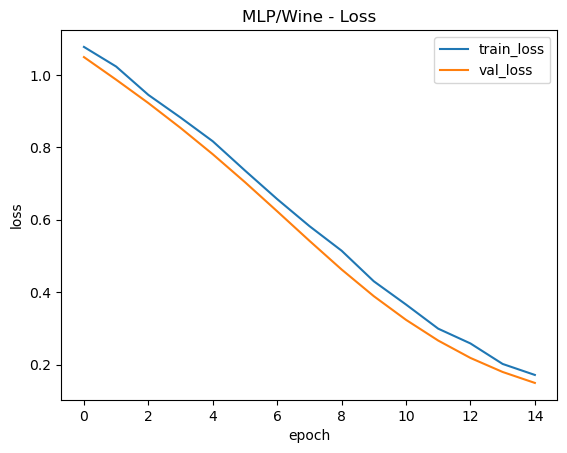

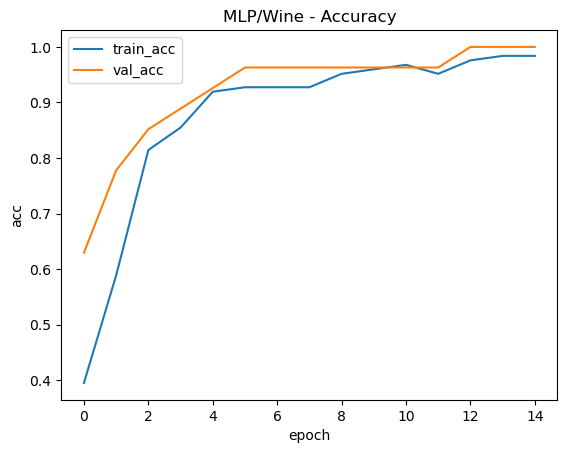

Test Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000         9
           1      1.000     1.000     1.000        11
           2      1.000     1.000     1.000         7

    accuracy                          1.000        27
   macro avg      1.000     1.000     1.000        27
weighted avg      1.000     1.000     1.000        27

Confusion Matrix:
 [[ 9  0  0]
 [ 0 11  0]
 [ 0  0  7]]


In [5]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_w = load_wine()
Xw = data_w['data'].astype(np.float32)
yw = data_w['target'].astype(np.int64)

Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(Xw, yw, test_size=0.3, stratify=yw, random_state=123)
Xv_w, Xt_w, yv_w, yt_w = train_test_split(Xte_w, yte_w, test_size=0.5, stratify=yte_w, random_state=123)

sc_w = StandardScaler()
Xtr_w = sc_w.fit_transform(Xtr_w).astype(np.float32)
Xv_w  = sc_w.transform(Xv_w).astype(np.float32)
Xt_w  = sc_w.transform(Xt_w).astype(np.float32)

train_w = DataLoader(TensorDataset(torch.tensor(Xtr_w), torch.tensor(ytr_w)), batch_size=32, shuffle=True)
val_w   = DataLoader(TensorDataset(torch.tensor(Xv_w), torch.tensor(yv_w)), batch_size=64)
test_w  = DataLoader(TensorDataset(torch.tensor(Xt_w), torch.tensor(yt_w)), batch_size=64)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, num_classes=3, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x): return self.net(x)

mlp_w = MLP(in_dim=Xw.shape[1], hidden=64, num_classes=len(np.unique(yw)), p=0.1).to(device)
opt = torch.optim.AdamW(mlp_w.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

hist={'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for ep in range(1, 16):
    mlp_w.train(); total=correct=0; loss_sum=0.0
    for xb, yb in train_w:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); logits = mlp_w(xb); loss = crit(logits, yb)
        loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        correct += (logits.argmax(1)==yb).sum().item(); total += xb.size(0)
    tr_loss = loss_sum/total; tr_acc = correct/total
    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)

    mlp_w.eval(); vtot=vcorr=0; vloss=0.0
    with torch.no_grad():
        for xv, yv in val_w:
            xv, yv = xv.to(device), yv.to(device)
            out = mlp_w(xv); l = crit(out, yv)
            vloss += l.item()*xv.size(0)
            vcorr += (out.argmax(1)==yv).sum().item(); vtot += xv.size(0)
    hist['val_loss'].append(vloss/vtot); hist['val_acc'].append(vcorr/vtot)
    print(f"Epoch {ep:02d}: train_loss={tr_loss:.4f} acc={tr_acc:.3f} | val_loss={vloss/vtot:.4f} acc={vcorr/vtot:.3f}")

plt.figure(); plt.plot(hist['train_loss'], label='train_loss'); plt.plot(hist['val_loss'], label='val_loss')
plt.title('MLP/Wine - Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

plt.figure(); plt.plot(hist['train_acc'], label='train_acc'); plt.plot(hist['val_acc'], label='val_acc')
plt.title('MLP/Wine - Accuracy'); plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend(); plt.show()

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
mlp_w.eval(); ys=[]; ps=[]
with torch.no_grad():
    for xb,yb in test_w:
        xb = xb.to(device)
        out = mlp_w(xb).cpu().argmax(1).numpy()
        ps.append(out); ys.append(yb.numpy())
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
print("Test Accuracy:", round(accuracy_score(y_true, y_pred),3))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

## 5) CNN — Demo phân loại ảnh (Fashion-MNIST; fallback: Digits)
**Mục tiêu:** Dùng CNN nhỏ cho bài toán ảnh.  
**Dữ liệu:** Thử tải **Fashion-MNIST**; nếu không có Internet → dùng **Digits** (8×8) của scikit-learn.

100%|██████████| 26.4M/26.4M [00:20<00:00, 1.30MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 163kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:02<00:00, 2.05MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.17MB/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Loaded Fashion-MNIST.
Epoch 1
Epoch 2
Epoch 3
CNN Test Accuracy: 0.887


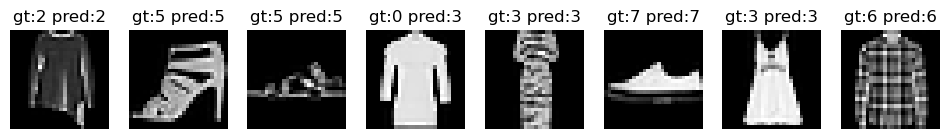

In [6]:
use_fashion = True
try:
    import torchvision
    from torchvision import datasets, transforms
    tfm = transforms.Compose([transforms.ToTensor()])
    train_set = datasets.FashionMNIST(root='./data', train=True, transform=tfm, download=True)
    test_set  = datasets.FashionMNIST(root='./data', train=False, transform=tfm, download=True)
    in_ch, im_size, num_classes = 1, 28, 10
    print("Loaded Fashion-MNIST.")
except Exception as e:
    print("Fashion-MNIST unavailable, fallback to sklearn digits:", e)
    use_fashion = False
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split
    digits = load_digits()
    Xd = digits.images.astype(np.float32)
    yd = digits.target.astype(np.int64)
    Xd = (Xd - Xd.min())/(Xd.max()-Xd.min()+1e-8)
    Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.2, stratify=yd, random_state=123)
    train_set = TensorDataset(torch.from_numpy(Xtr[:,None,:,:]), torch.from_numpy(ytr))
    test_set  = TensorDataset(torch.from_numpy(Xte[:,None,:,:]), torch.from_numpy(yte))
    in_ch, im_size, num_classes = 1, 8, len(np.unique(yd))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=128)

class SmallCNN(nn.Module):
    def __init__(self, in_ch=1, num_classes=10, im_size=28):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        out_hw = im_size // 4
        self.cls = nn.Sequential(nn.Flatten(), nn.Linear(32*out_hw*out_hw, 64), nn.ReLU(), nn.Linear(64, num_classes))
    def forward(self, x): return self.cls(self.feat(x))

cnn = SmallCNN(in_ch=in_ch, num_classes=num_classes, im_size=im_size).to(device)
opt = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

for ep in range(1, 4):
    cnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = crit(cnn(xb), yb); loss.backward(); opt.step()
    print("Epoch", ep)

from sklearn.metrics import accuracy_score
cnn.eval(); ys=[]; ps=[]
with torch.no_grad():
    for xb,yb in test_loader:
        xb = xb.to(device)
        out = cnn(xb).cpu().argmax(1).numpy()
        ys.append(yb.numpy()); ps.append(out)
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
print("CNN Test Accuracy:", round(accuracy_score(y_true, y_pred),3))

def show_samples(model, dataset, n=8):
    model.eval()
    idx = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    imgs, labels, preds = [], [], []
    with torch.no_grad():
        for i in idx:
            x, y = dataset[i]
            p = model(x.to(device).unsqueeze(0)).argmax(1).item()
            imgs.append(x.squeeze().cpu().numpy()); labels.append(int(y)); preds.append(int(p))
    plt.figure(figsize=(12,2.8))
    for i, im in enumerate(imgs):
        plt.subplot(1, len(imgs), i+1); plt.imshow(im, cmap='gray')
        plt.title(f"gt:{labels[i]} pred:{preds[i]}"); plt.axis('off')
    plt.show()

show_samples(cnn, test_set, n=8)

## 6) RNN — LSTM — GRU — Demo phân loại cảm xúc (tập câu ngắn)
**Mục tiêu:** Pipeline văn bản tuần tự: tokenize → vocab → padding → LSTM.  
**Dữ liệu:** Tập câu ngắn (thực tế mô phỏng). *Gợi ý:* Khi online, thay bằng IMDB.

In [7]:
import re
from collections import Counter

small_texts = [
    ("This movie was fantastic, I loved every moment.", 1),
    ("Absolutely terrible. Waste of time.", 0),
    ("Great performances and beautiful cinematography.", 1),
    ("The plot was boring and predictable.", 0),
    ("I would watch it again, highly recommended!", 1),
    ("Not my taste, the acting felt wooden.", 0),
    ("An inspiring story, well told.", 1),
    ("I fell asleep halfway through.", 0),
    ("Brilliant soundtrack and engaging script.", 1),
    ("Poor editing and weak dialogue.", 0),
    ("Loved the characters and pacing.", 1),
    ("It was okay, nothing special.", 0),
    ("Heartwarming and memorable.", 1),
    ("Confusing plot with many holes.", 0),
    ("A masterpiece!", 1),
    ("Worst film I've seen this year.", 0),
]

def tok(s):
    s = re.sub(r"[^a-z0-9\s']", " ", s.lower())
    return s.split()

cnt = Counter()
for t,_ in small_texts:
    cnt.update(tok(t))

stoi = {"<pad>":0, "<unk>":1}
for w,_ in cnt.most_common(2000):
    if w not in stoi: stoi[w] = len(stoi)

def encode(text, L=24):
    ids = [stoi.get(w,1) for w in tok(text)][:L]
    if len(ids) < L: ids += [0]*(L-len(ids))
    return ids

import numpy as np
X = np.array([encode(t) for t,_ in small_texts], dtype=np.int64)
y = np.array([y for _,y in small_texts], dtype=np.int64)

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=123)

train_rnn = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=4, shuffle=True)
test_rnn  = DataLoader(TensorDataset(torch.tensor(Xte), torch.tensor(yte)), batch_size=4)

class LSTMSent(nn.Module):
    def __init__(self, V, E=64, H=64, C=2):
        super().__init__()
        self.emb = nn.Embedding(V, E, padding_idx=0)
        self.lstm = nn.LSTM(E, H, batch_first=True)
        self.fc = nn.Linear(H, C)
    def forward(self, x):
        e = self.emb(x); out, (h,c) = self.lstm(e); h = h[-1]
        return self.fc(h)

rnn = LSTMSent(V=len(stoi)).to(device)
opt = torch.optim.AdamW(rnn.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

for ep in range(1, 21):
    rnn.train()
    for xb,yb in train_rnn:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = crit(rnn(xb), yb); loss.backward(); opt.step()
    if ep%5==0: print("Epoch", ep)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rnn.eval(); ys=[]; ps=[]
with torch.no_grad():
    for xb,yb in test_rnn:
        xb = xb.to(device)
        out = rnn(xb).cpu().argmax(1).numpy()
        ys.append(yb.numpy()); ps.append(out)
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
print("LSTM Test Accuracy (tiny set):", round(accuracy_score(y_true, y_pred),3))
print("\\nClassification report:\\n", classification_report(y_true, y_pred, digits=3))
print("Confusion Matrix:\\n", confusion_matrix(y_true, y_pred))

def predict(text):
    ids = torch.tensor(encode(text))[None,:].to(device)
    with torch.no_grad():
        p = rnn(ids).softmax(1).squeeze().cpu().numpy()
    return {"neg": float(p[0]), "pos": float(p[1])}

predict("The movie was surprisingly good and touching.")

Epoch 5
Epoch 10
Epoch 15
Epoch 20
LSTM Test Accuracy (tiny set): 0.5
\nClassification report:\n               precision    recall  f1-score   support

           0      0.500     1.000     0.667         2
           1      0.000     0.000     0.000         2

    accuracy                          0.500         4
   macro avg      0.250     0.500     0.333         4
weighted avg      0.250     0.500     0.333         4

Confusion Matrix:\n [[2 0]
 [2 0]]


c:\Users\Orias.ASUS\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Orias.ASUS\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Orias.ASUS\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

{'neg': 0.5043959617614746, 'pos': 0.4956040382385254}

## 7) Transformer — Demo **Vision Transformer (ViT)** nhỏ trên **Digits**
**Mục tiêu:** Thấy quy trình patch embedding + self-attention bằng `nn.TransformerEncoder`.  
**Dữ liệu:** `sklearn.datasets.load_digits()` (ảnh 8×8) → chia thành patch 2×2 (16 patch).

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
Xd = digits.images.astype(np.float32)  # [n, 8, 8]
yd = digits.target.astype(np.int64)

Xd = (Xd - Xd.min())/(Xd.max()-Xd.min()+1e-8)

def patchify(images):
    N, H, W = images.shape
    ph = pw = 2
    patches = []
    for img in images:
        ps = []
        for i in range(0,H,ph):
            for j in range(0,W,pw):
                p = img[i:i+ph, j:j+pw].reshape(-1)  # 4-dim
                ps.append(p)
        patches.append(np.stack(ps, axis=0))  # [16,4]
    return np.stack(patches, axis=0)  # [N, 16, 4]

Xp = patchify(Xd)  # [N, 16, 4]

Xtr, Xte, ytr, yte = train_test_split(Xp, yd, test_size=0.2, stratify=yd, random_state=123)
train_vit = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=64, shuffle=True)
test_vit  = DataLoader(TensorDataset(torch.tensor(Xte), torch.tensor(yte)), batch_size=128)

class TinyViT(nn.Module):
    def __init__(self, patch_dim=4, num_patches=16, emb=32, num_classes=10, nhead=4, nlayers=2):
        super().__init__()
        self.cls = nn.Parameter(torch.randn(1,1,emb))
        self.pos = nn.Parameter(torch.randn(1, num_patches+1, emb))
        self.embed = nn.Linear(patch_dim, emb)
        enc_layer = nn.TransformerEncoderLayer(d_model=emb, nhead=nhead, dim_feedforward=64, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.head = nn.Linear(emb, num_classes)
    def forward(self, x):             # x: [B, 16, 4]
        B = x.size(0)
        e = self.embed(x)             # [B, 16, emb]
        cls = self.cls.expand(B, -1, -1)
        e = torch.cat([cls, e], dim=1) + self.pos  # [B, 17, emb]
        h = self.encoder(e)            # [B, 17, emb]
        return self.head(h[:,0])      # dùng cls token

vit = TinyViT().to(device)
opt = torch.optim.AdamW(vit.parameters(), lr=2e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

for ep in range(1, 6):
    vit.train()
    for xb,yb in train_vit:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = crit(vit(xb), yb); loss.backward(); opt.step()
    print("Epoch", ep)

from sklearn.metrics import accuracy_score
vit.eval(); ys=[]; ps=[]
with torch.no_grad():
    for xb,yb in test_vit:
        xb = xb.to(device)
        out = vit(xb).cpu().argmax(1).numpy()
        ys.append(yb.numpy()); ps.append(out)
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
print("TinyViT Test Accuracy (Digits):", round(accuracy_score(y_true, y_pred),3))

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
TinyViT Test Accuracy (Digits): 0.856


## 8) GAN — Demo tạo ảnh **Digits 8×8** (nhanh, tối giản)
**Mục tiêu:** Thấy cơ chế Generator vs Discriminator; chạy ít bước để minh hoạ.  
**Dữ liệu:** `Digits` 8×8 (thật). Ảnh đầu ra hiển thị dạng lưới.

Step 0: lossD=1.381 lossG=0.761


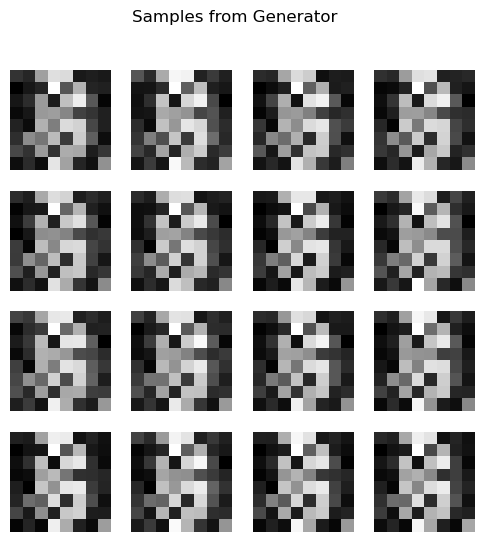

In [9]:
X = digits.images.astype(np.float32)
X = (X - X.min())/(X.max()-X.min()+1e-8)
X = X.reshape(len(X), -1)  # [N, 64]
X = torch.tensor(X)

batch_size = 128
dl = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)

z_dim = 32

class Gen(nn.Module):
    def __init__(self, z=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.Sigmoid()  # output in [0,1]
        )
    def forward(self, z): return self.net(z)

class Disc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G, D = Gen(z_dim).to(device), Disc().to(device)
optG = torch.optim.Adam(G.parameters(), lr=2e-3)
optD = torch.optim.Adam(D.parameters(), lr=2e-3)
bce = nn.BCELoss()

def sample_grid(model, n=16):
    with torch.no_grad():
        z = torch.randn(n, z_dim, device=device)
        x = model(z).cpu().numpy().reshape(n, 8, 8)
    cols = int(math.sqrt(n)); rows = math.ceil(n/cols)
    plt.figure(figsize=(6,6))
    for i in range(n):
        plt.subplot(rows, cols, i+1); plt.imshow(x[i], cmap='gray'); plt.axis('off')
    plt.suptitle("Samples from Generator"); plt.show()

steps = 400  # ngắn cho minh hoạ
for step, (xb,) in enumerate(dl):
    if step >= steps: break
    xb = xb.to(device)
    # Train D
    optD.zero_grad()
    real = xb
    z = torch.randn(xb.size(0), z_dim, device=device)
    fake = G(z).detach()
    lossD = bce(D(real), torch.ones(len(real),1, device=device)) +             bce(D(fake), torch.zeros(len(fake),1, device=device))
    lossD.backward(); optD.step()
    # Train G
    optG.zero_grad()
    z = torch.randn(xb.size(0), z_dim, device=device)
    fake = G(z)
    lossG = bce(D(fake), torch.ones(len(fake),1, device=device))
    lossG.backward(); optG.step()
    if step % 100 == 0:
        print(f"Step {step}: lossD={lossD.item():.3f} lossG={lossG.item():.3f}")

sample_grid(G, n=16)

## 9) Autoencoder — Demo khử nhiễu ảnh **Digits 8×8**
**Mục tiêu:** Thấy encoder–decoder tái tạo ảnh và khả năng khử nhiễu nhẹ.  
**Dữ liệu:** `Digits` 8×8.

Epoch 1: recon_loss=0.1774
Epoch 2: recon_loss=0.1574
Epoch 3: recon_loss=0.1167
Epoch 4: recon_loss=0.0858
Epoch 5: recon_loss=0.0762
Epoch 6: recon_loss=0.0743
Epoch 7: recon_loss=0.0734
Epoch 8: recon_loss=0.0730
Epoch 9: recon_loss=0.0726
Epoch 10: recon_loss=0.0720


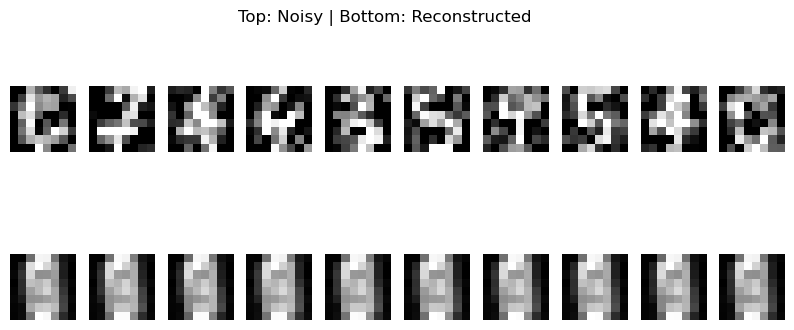

In [10]:
def add_noise(x, scale=0.3):
    n = torch.randn_like(x)*scale
    y = (x + n).clamp(0,1)
    return y

train_ae = DataLoader(TensorDataset(X), batch_size=128, shuffle=True)

class AE(nn.Module):
    def __init__(self, d=64, h=32, z=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Linear(h,z))
        self.dec = nn.Sequential(nn.Linear(z,h), nn.ReLU(), nn.Linear(h,d), nn.Sigmoid())
    def forward(self, x):
        z = self.enc(x); out = self.dec(z); return out

ae = AE().to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for ep in range(1, 11):
    ae.train(); loss_sum=0; n=0
    for (xb,) in train_ae:
        xb = xb.to(device)
        noisy = add_noise(xb, scale=0.25)
        opt.zero_grad(); out = ae(noisy); loss = loss_fn(out, xb)
        loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0); n += xb.size(0)
    print(f"Epoch {ep}: recon_loss={loss_sum/n:.4f}")

ae.eval()
with torch.no_grad():
    import numpy as np
    idx = np.random.choice(len(X), size=10, replace=False)
    noisy = add_noise(X[idx].to(device), scale=0.25)
    recon = ae(noisy).cpu().numpy().reshape(-1,8,8)
    noisy = noisy.cpu().numpy().reshape(-1,8,8)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,10,i+1); plt.imshow(noisy[i], cmap='gray'); plt.axis('off')
    plt.subplot(2,10,10+i+1); plt.imshow(recon[i], cmap='gray'); plt.axis('off')
plt.suptitle("Top: Noisy | Bottom: Reconstructed")
plt.show()

## 10) Gợi ý lộ trình tự học — Checklist thực hành (không bắt buộc chạy)
- Ôn Python, đại số tuyến tính, xác suất–thống kê, giải tích.
- Hoàn thành: MLP (Wine), CNN (Fashion/Digits), LSTM (sentiment).
- Khám phá ViT (Transformer encoder) và so sánh với CNN trên Digits.
- Thử GAN, AE với Digits; viết nhận xét ngắn (5–10 dòng).

## 11) Thuật ngữ chính — Ôn tập nhanh
- **Activation function**: sigmoid, tanh, ReLU…  
- **Convolution**: trích xuất đặc trưng cục bộ.  
- **Self-Attention**: chú ý giữa các vị trí của cùng chuỗi.  
- **Positional Encoding**: mã hoá vị trí token cho Transformer.  
- **Generator/Discriminator**: 2 mạng đối đầu trong GAN.  
- **Encoder/Decoder**: nén & giải nén (AE, Transformer).

## 12) Kết luận
Notebook này gồm **bài thực hành demo** cho: Perceptron, **MLP**, **CNN**, **RNN/LSTM**, **Transformer (ViT nhỏ)**, **GAN**, **Autoencoder** — dùng **dữ liệu thật** (Iris/Wine/Digits) hoặc câu thực tế rút gọn (sentiment).  
Hãy điều chỉnh siêu tham số và ghi lại quan sát để hiểu sâu hơn.